<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/K_MEANS_OFFICIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Agrupamiento K-Means

Este cuaderno explora la aplicación del algoritmo K-Means para la segmentación de datos en 2 y 3 dimensiones, utilizando ejemplos prácticos del géiser Old Faithful y un análisis RFM de transacciones de clientes.

In [1]:
from google.colab import drive
import pandas as pd

drive.mount('/content/gdrive')

# CAMBIO 1: Apuntamos al nuevo archivo faithful.csv
ruta_archivo = '/content/gdrive/MyDrive/SIS420IA/faithful.csv'
df = pd.read_csv(ruta_archivo)

print(df.head(5))
print(df.columns.tolist())

Mounted at /content/gdrive
   Unnamed: 0  eruptions  waiting
0           1      3.600       79
1           2      1.800       54
2           3      3.333       74
3           4      2.283       62
4           5      4.533       85
['Unnamed: 0', 'eruptions', 'waiting']


# Análisis 2D - Géiser Old Faithful

En esta sección, aplicaremos el algoritmo K-Means a un dataset bidimensional. Utilizaremos el famoso conjunto de datos del géiser Old Faithful, que contiene información sobre la duración de las erupciones y el tiempo de espera entre ellas, para identificar patrones naturales de agrupamiento.

**Selección de columnas (Erupciones y Espera)**

In [2]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# CAMBIO 2: Cambiamos los nombres de las columnas a extraer
X_2d = df[['eruptions', 'waiting']].values

**Búsqueda del K óptimo**

In [3]:
rango_k = range(2, 11)
silhouette_scores_2d = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_2d)
    score = silhouette_score(X_2d, kmeans.labels_)
    silhouette_scores_2d.append(score)
    print("K=", k, " -> Silueta:", score)

K= 2  -> Silueta: 0.724054851995858
K= 3  -> Silueta: 0.583617622775959
K= 4  -> Silueta: 0.5434232196327469
K= 5  -> Silueta: 0.4983428132299225
K= 6  -> Silueta: 0.5331793518020691
K= 7  -> Silueta: 0.5450368394997572
K= 8  -> Silueta: 0.5238475618598685
K= 9  -> Silueta: 0.5428094887033891
K= 10  -> Silueta: 0.5403700029701033


**Entrenamiento del modelo final 2D**

In [4]:
# CAMBIO 3: Ajustamos el K al que nos dio mejor puntaje (seguramente 2)
mejor_k_2d = 2
kmeans_2d = KMeans(n_clusters=mejor_k_2d, random_state=42, n_init='auto')
kmeans_2d.fit(X_2d)

centroides_2d = kmeans_2d.cluster_centers_

**Definición de funciones de estilo gráfico**

In [5]:
import matplotlib.pyplot as plt

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    # CAMBIO 4: Etiquetas de los ejes actualizadas
    if show_xlabels:
        plt.xlabel("Duracion de la Erupcion (minutos)", fontsize=12)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("Tiempo de Espera (minutos)", fontsize=12, rotation=90)
    else:
        plt.tick_params(labelleft=False)

**Visualización Final en 2D**

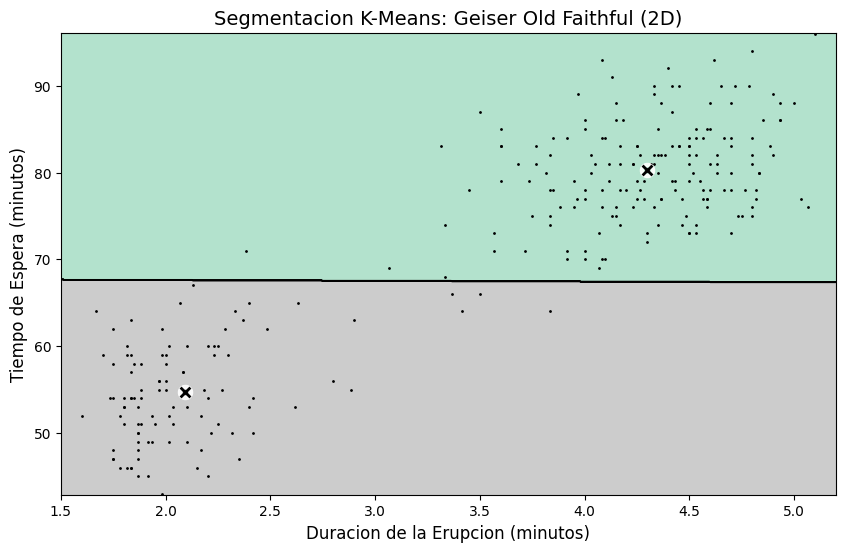

In [6]:
plt.figure(figsize=(10, 6))
plot_decision_boundaries(kmeans_2d, X_2d)
# CAMBIO 5: Título actualizado
plt.title("Segmentacion K-Means: Geiser Old Faithful (2D)", fontsize=14)
plt.show()

---

# Análisis 3D - Carga y Transformación RFM
Como nuestro dataset es un registro de compras diarias, vamos a agrupar los datos por cliente (CustomerID) y a calcular 3 nuevas variables (Recencia, Frecuencia y Valor Monetario) para crear nuestro espacio 3D.

In [7]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Cargar el dataset de transacciones
ruta_archivo = '/content/gdrive/MyDrive/SIS420IA/rfm_data.csv'
df = pd.read_csv(ruta_archivo)

# 2. Convertir la fecha a formato Date de Pandas
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# 3. Calcular fecha máxima para medir la "Recencia" (días desde la última compra)
fecha_actual = df['PurchaseDate'].max() + pd.Timedelta(days=1)

# 4. Agrupar por Cliente y crear la tabla RFM (Nuestras 3 Dimensiones)
df_rfm = df.groupby('CustomerID').agg({
    'PurchaseDate': lambda x: (fecha_actual - x.max()).days, # Recency
    'OrderID': 'count',                                      # Frequency
    'TransactionAmount': 'sum'                               # Monetary
}).reset_index()

# Renombrar columnas
df_rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("Dataset convertido a 3D (RFM). Primeros 5 clientes:")
print(df_rfm.head())

# Extraer nuestra variable X en 3D
X_3d = df_rfm[['Recency', 'Frequency', 'Monetary']].values

Dataset convertido a 3D (RFM). Primeros 5 clientes:
   CustomerID  Recency  Frequency  Monetary
0        1011       34          2   1129.02
1        1025       22          1    359.29
2        1029        1          1    704.99
3        1046       44          1    859.82
4        1049       14          1    225.72


Búsqueda del K óptimo para el RFM
Calculamos el Coeficiente de Silueta probando agrupaciones del 2 al 10 para ver cómo la matemática agrupa mejor a estos clientes en nuestro nuevo espacio de 3 dimensiones. **texto en negrita**

In [8]:
print("--- CALCULANDO K ÓPTIMO PARA 3D (RFM) ---")
rango_k = range(2, 11)
silhouette_scores_3d = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_3d)
    score = silhouette_score(X_3d, kmeans.labels_)
    silhouette_scores_3d.append(score)
    print(f"K={k} -> Silueta: {score:.4f}")

--- CALCULANDO K ÓPTIMO PARA 3D (RFM) ---
K=2 -> Silueta: 0.6071
K=3 -> Silueta: 0.5441
K=4 -> Silueta: 0.5722
K=5 -> Silueta: 0.5440
K=6 -> Silueta: 0.5246
K=7 -> Silueta: 0.5252
K=8 -> Silueta: 0.5265
K=9 -> Silueta: 0.5126
K=10 -> Silueta: 0.4871


**Entrenamiento del modelo final 3D**

In [13]:
mejor_k_3d = 2
kmeans_3d = KMeans(n_clusters=mejor_k_3d, random_state=42, n_init='auto')

# Entrenar y predecir
y_predict_3d = kmeans_3d.fit_predict(X_3d)

# Obtener centroides
centroides_3d = kmeans_3d.cluster_centers_

**Visualización Final 3D (Modelo RFM)**

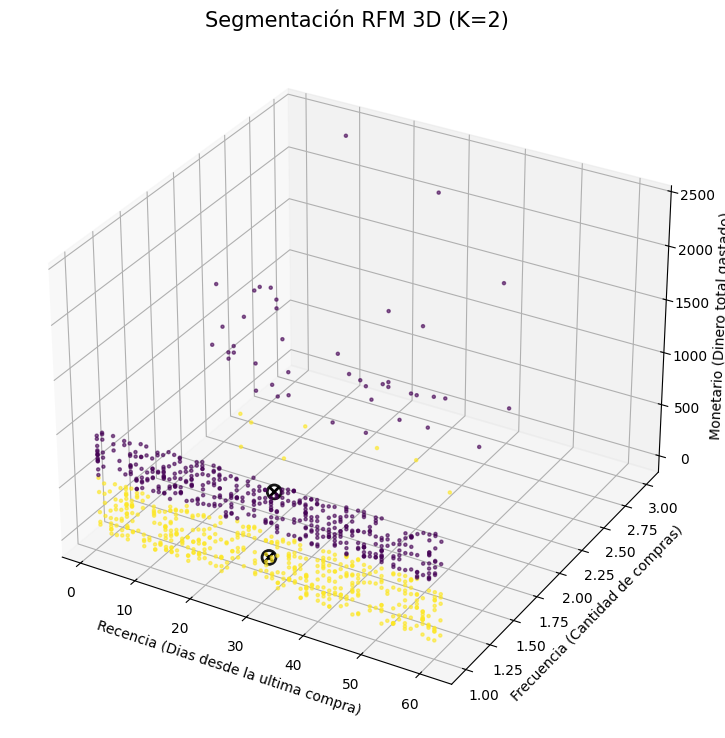

In [16]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Graficar los clientes, coloreados según su cluster predicho
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
           c=y_predict_3d, cmap='viridis', marker='.', s=20, alpha=0.6)

# Graficar los centroides (Círculo blanco)
ax.scatter(centroides_3d[:, 0], centroides_3d[:, 1], centroides_3d[:, 2],
           marker='o', s=100, linewidths=2, color='white', edgecolor='black', zorder=10, alpha=0.9)

# Graficar los centroides (Cruz negra)
ax.scatter(centroides_3d[:, 0], centroides_3d[:, 1], centroides_3d[:, 2],
           marker='x', s=50, linewidths=2, color='black', zorder=11, alpha=1)

ax.set_title(f"Segmentación RFM 3D (K={mejor_k_3d})", fontsize=15)
# Actualizamos los ejes a las variables del análisis RFM
ax.set_xlabel('Recencia (Dias desde la ultima compra)')
ax.set_ylabel('Frecuencia (Cantidad de compras)')
ax.set_zlabel('Monetario (Dinero total gastado)')

plt.show()

## Conclusiones y Siguientes Pasos

Este cuaderno ha demostrado cómo aplicar el algoritmo K-Means para la segmentación de datos en 2 y 3 dimensiones. Hemos utilizado el coeficiente de silueta para determinar un número óptimo de clusters en ambos casos. Los resultados visuales nos permiten entender las agrupaciones identificadas por el algoritmo.

Para futuras mejoras, se podría considerar:
*   **Normalización de datos:** Especialmente en el análisis RFM, las diferentes escalas de las variables podrían influir en el clustering.
*   **Otros algoritmos de clustering:** Explorar algoritmos como DBSCAN o Agglomerative Clustering.
*   **Interpretación de clusters:** Analizar las características de cada cluster para darles un significado de negocio (ej. 'Clientes VIP', 'Clientes de bajo valor').